# Exploratory Data Analysis (EDA) - [Titanic - Machine Learning from Disaster]

**Objective**: Predict passenger survival on the Titanic using machine learning through cleaning, and feature analysis, and model training

**Data Source**: [Kaggle: Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

## Packages installation and libraries importation

In [53]:
pip install pandas numpy matplotlib torch scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
# Some common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [55]:
df = pd.read_csv('data/train.csv')
print(f"Initial dataset shape: {df.shape}")
print(df.shape)
df.head()

Initial dataset shape: (891, 12)
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data overview

In [56]:
print("Data info:")
df.info()
df.describe()
print("\nMissing values per column:")
print(df.isna().sum())
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          

- Pclass: A proxy for socio-economic status (SES)
    + 1st = Upper
    + 2nd = Middle
    + 3rd = Lower

- Age: Age is fractional if less than 1, it in the form of x.5 if estimated

- Sibsp: The dataset defines family relations
    + Sibling = brother, sister, stepbrother, stepsister
    + Spouse = husband, wife (mistresses and fiancés were ignored)

- Parch: The dataset defines family relations in this way...
    + Parent = mother, father
    + Child = daughter, son, stepdaughter, stepson
    + Some children travelled only with a nanny, therefore parch=0 for them.

In [57]:
# Fill missing ages and embarks with median, and most frequent port based on Pclass and Sex
df.fillna({'Age': df.groupby(['Pclass', 'Sex'])['Age'].transform('median')}, inplace=True)
df.fillna({'Embarked': df.groupby(['Pclass', 'Sex'])['Embarked'].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')}, inplace=True)   

Most of the values in Cabin are missing, and PassengerId is irrelevant for analysis

In [58]:
df = df.drop(['PassengerId', 'Cabin'], axis=1)

## Data transformation and encoding

In [59]:
# Change the keys to better readable ones
df['Embarked'] = df['Embarked'].replace(['C','S','Q'], ['Cherbourg','Southampton','Queenstown'])
df['Survived'] = df['Survived'].replace([0, 1], ['No', 'Yes'])
df['Pclass'] = df['Pclass'].replace([1, 2, 3], ['Upper', 'Middle', 'Lower'])

In [60]:
# Convert age values into ordered age groups
df['Age'] = pd.cut(df['Age'], bins=[0, 5, 12, 18, 65, 150], labels=['Infant', 'Child', 'Teenager', 'Adult', 'Senior'])
# Combine siblings and parch to represent the total family members all board
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.drop(columns=['SibSp', 'Parch'], inplace=True)

In [61]:
categorical_df = df.loc[:, df.nunique() <= 10]
print("Categorical features: ", categorical_df.columns.values)

numerical_df = df.loc[:, df.nunique() > 10]
numerical_df = numerical_df.select_dtypes(include='number')
print("Numerical features: ", numerical_df.columns.values)

Categorical features:  ['Survived' 'Pclass' 'Sex' 'Age' 'Embarked' 'FamilySize']
Numerical features:  ['Fare']


## Univariate Analysis

Mean: 32.204207968574636 
Median: 14.4542


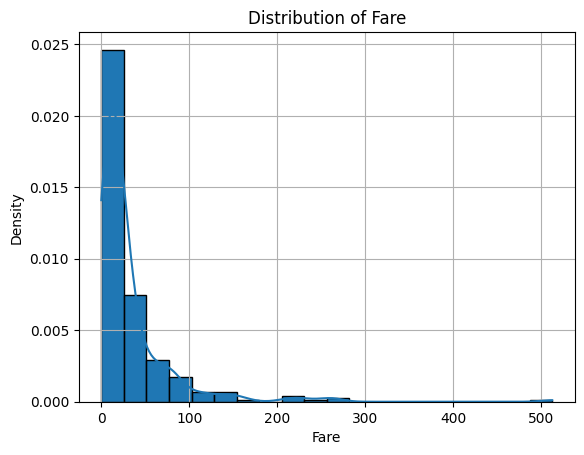

In [62]:
import seaborn as sns
for col in numerical_df.columns:
    numerical_df[col].dropna().hist(bins=20, density=True)
    sns.histplot(numerical_df[col], bins=20, kde=True, stat="density")
    print(f'Mean: {numerical_df[col].mean()} \nMedian: {numerical_df[col].median()}')
    plt.title(f'Distribution of {col}')
    plt.show()

In [63]:
def group_by_col_and_plot(df, col):
    gr = df.groupby(col).size().to_frame(name='Count')
    gr['Ratio'] = np.round(gr['Count'] / gr['Count'].sum() * 100, 0)
    
    print(f'Total number of {col}: {gr["Count"].sum()}')
    
    colors = sns.color_palette(n_colors=len(gr))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr['Count'].plot(kind='bar', ax=ax1, color=colors, title=f'{col} Counts')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr['Ratio'].plot(kind='pie', ax=ax2, colors=colors, title=f'{col} Ratio', autopct='%1.1f%%', ylabel='')   

    plt.tight_layout()
    plt.show()
    
def is_category_significant(df):
    

SyntaxError: incomplete input (1301503776.py, line 25)

Total number of Survived: 891


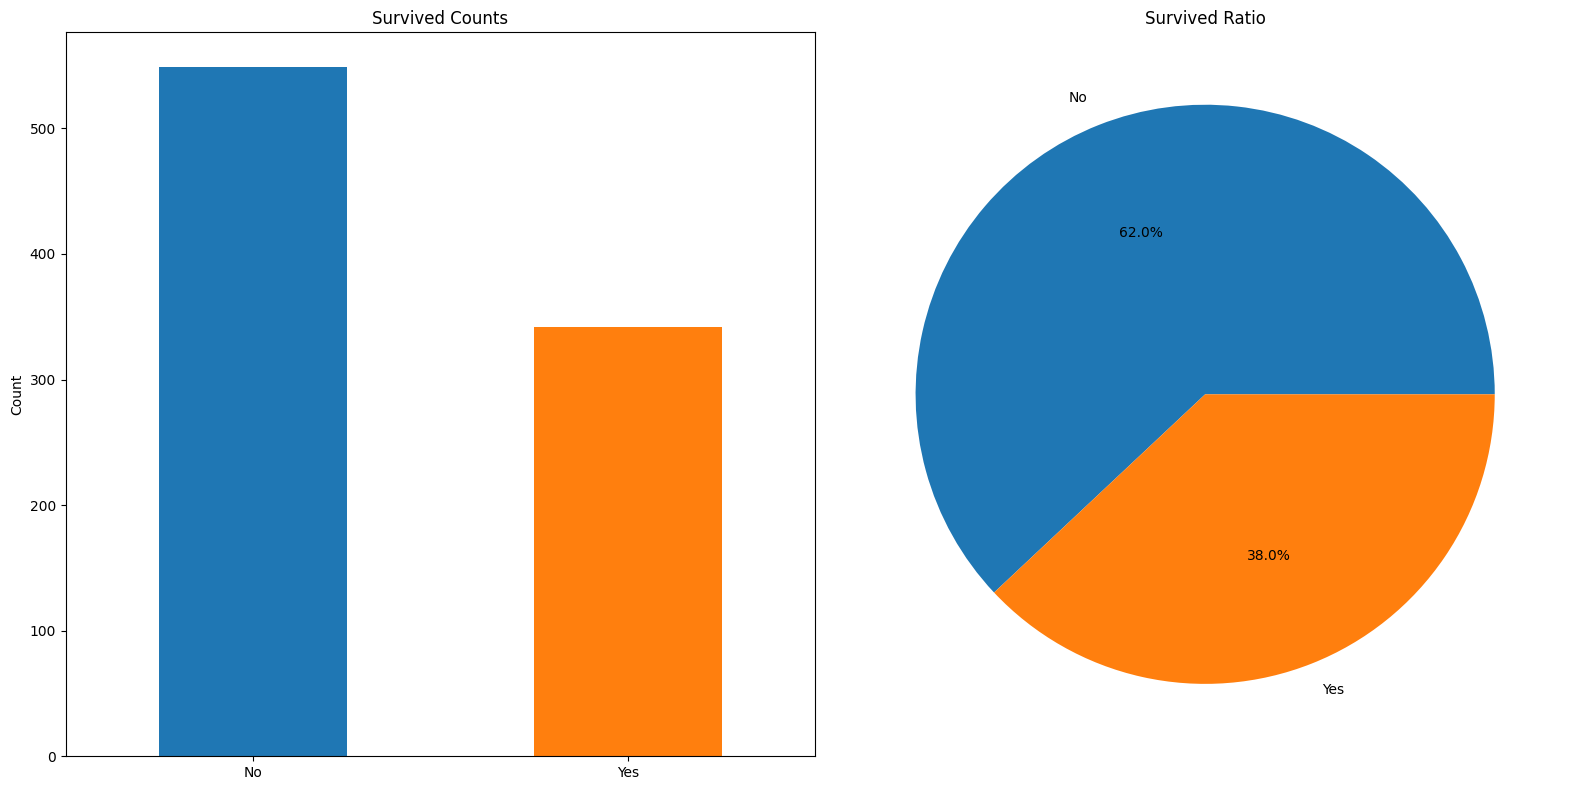

Total number of Pclass: 891


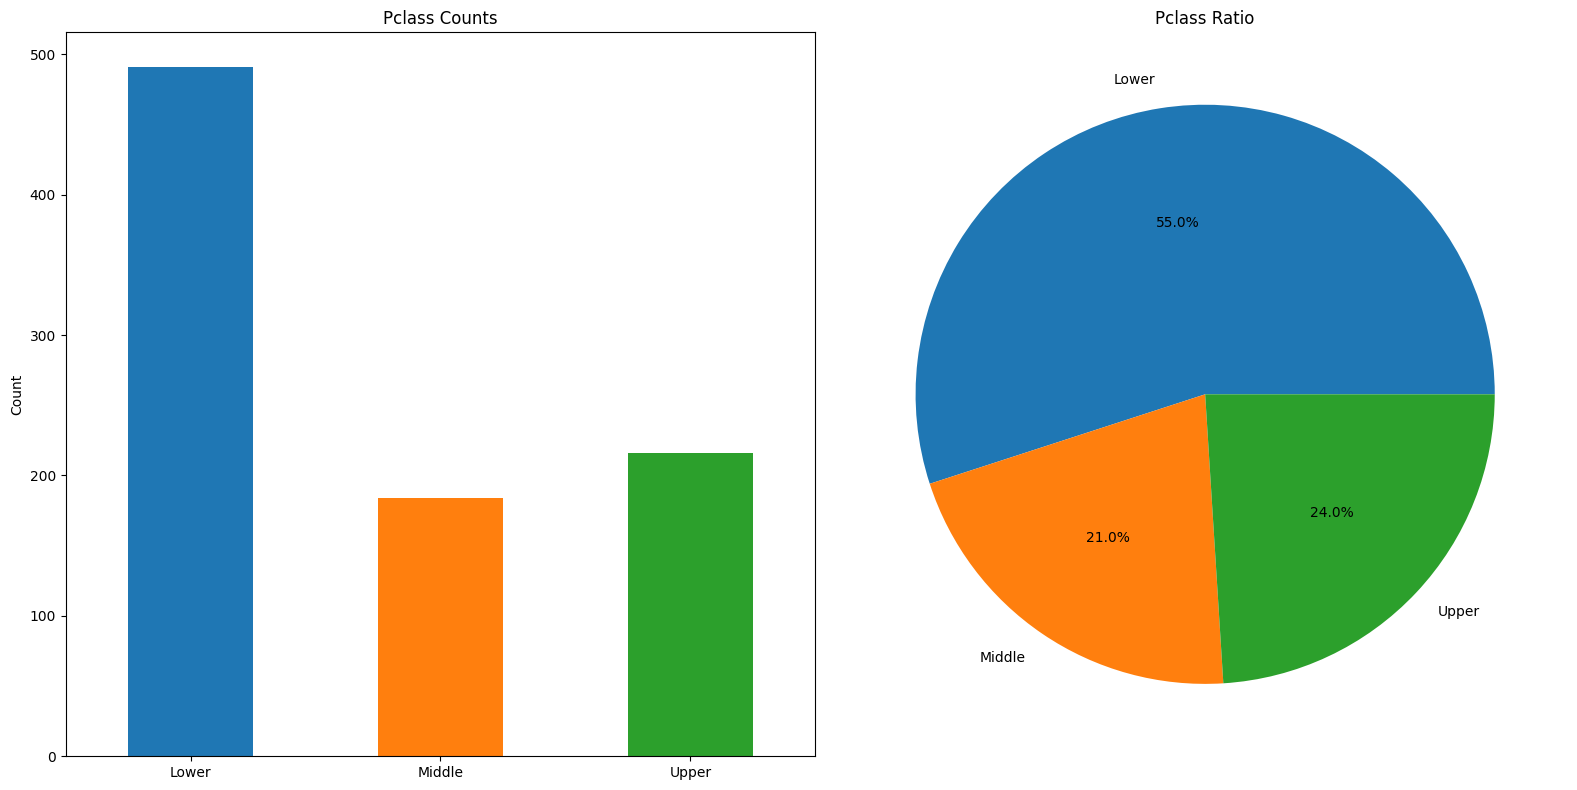

Total number of Sex: 891


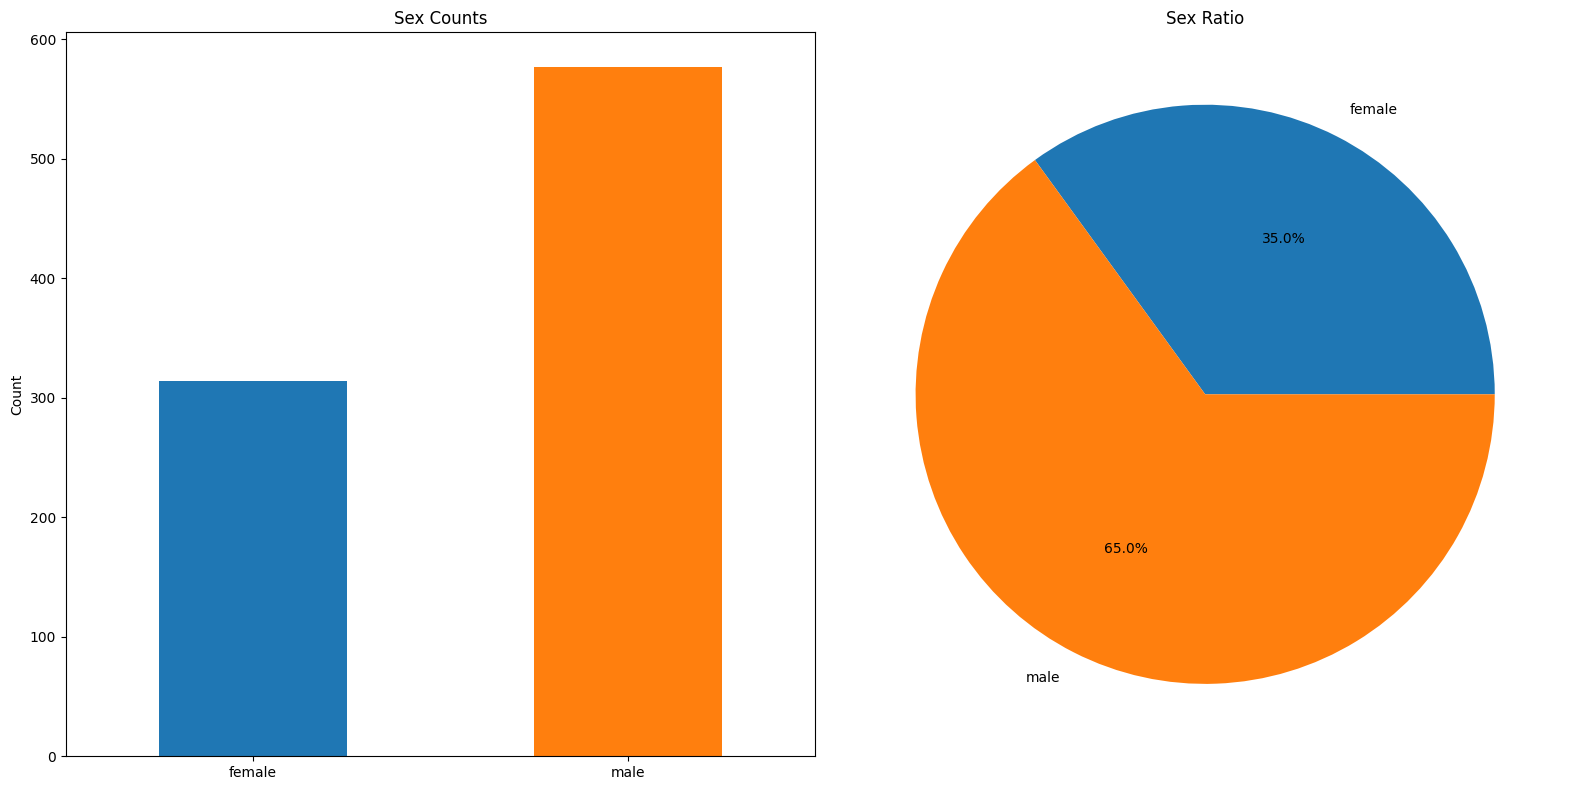

/tmp/ipykernel_2170/2423364013.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gr = df.groupby(col).size().to_frame(name='Count')


Total number of Age: 891


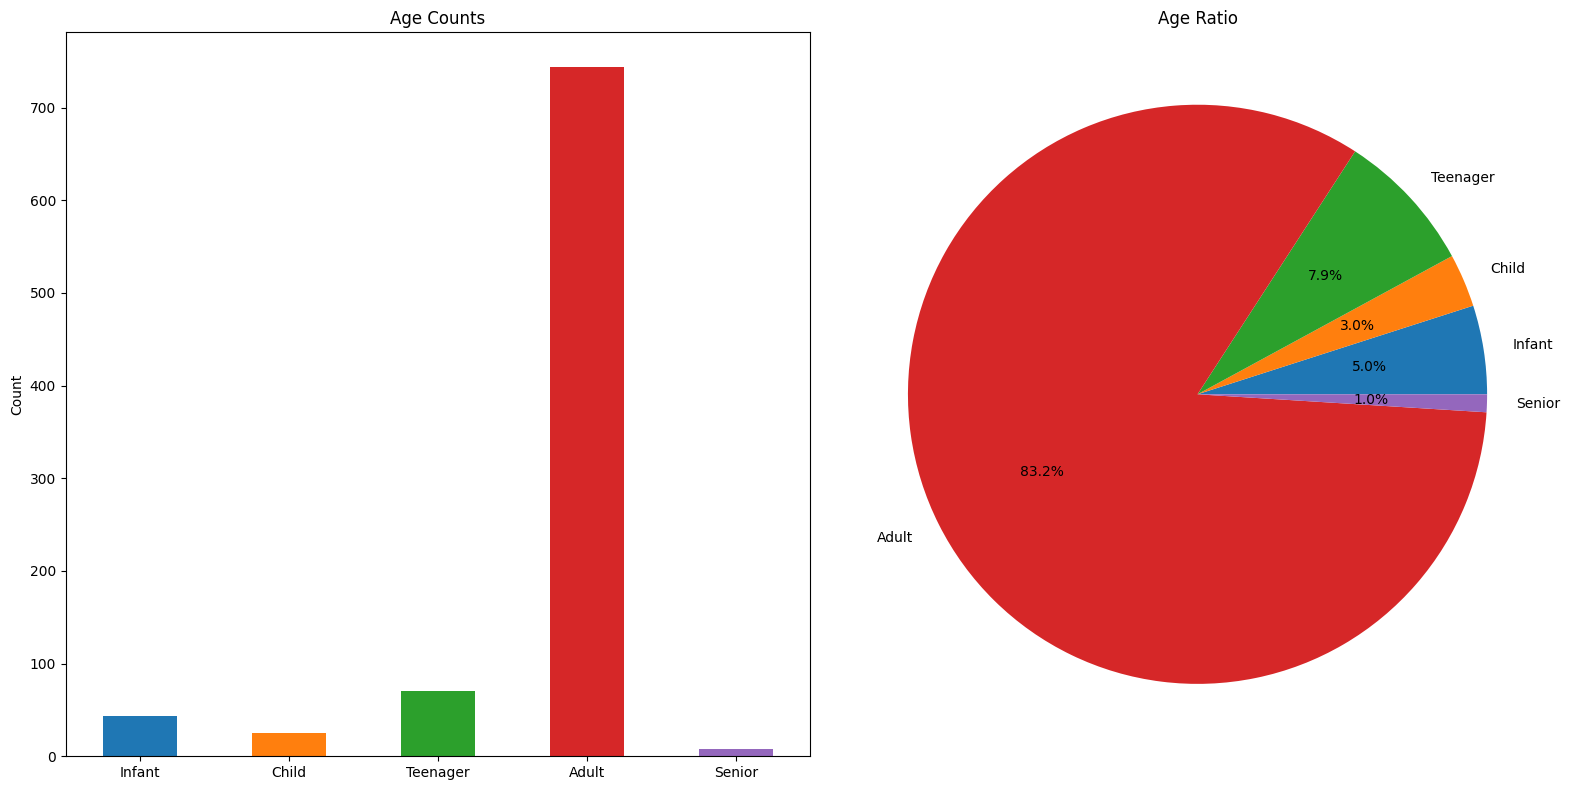

Total number of Embarked: 891


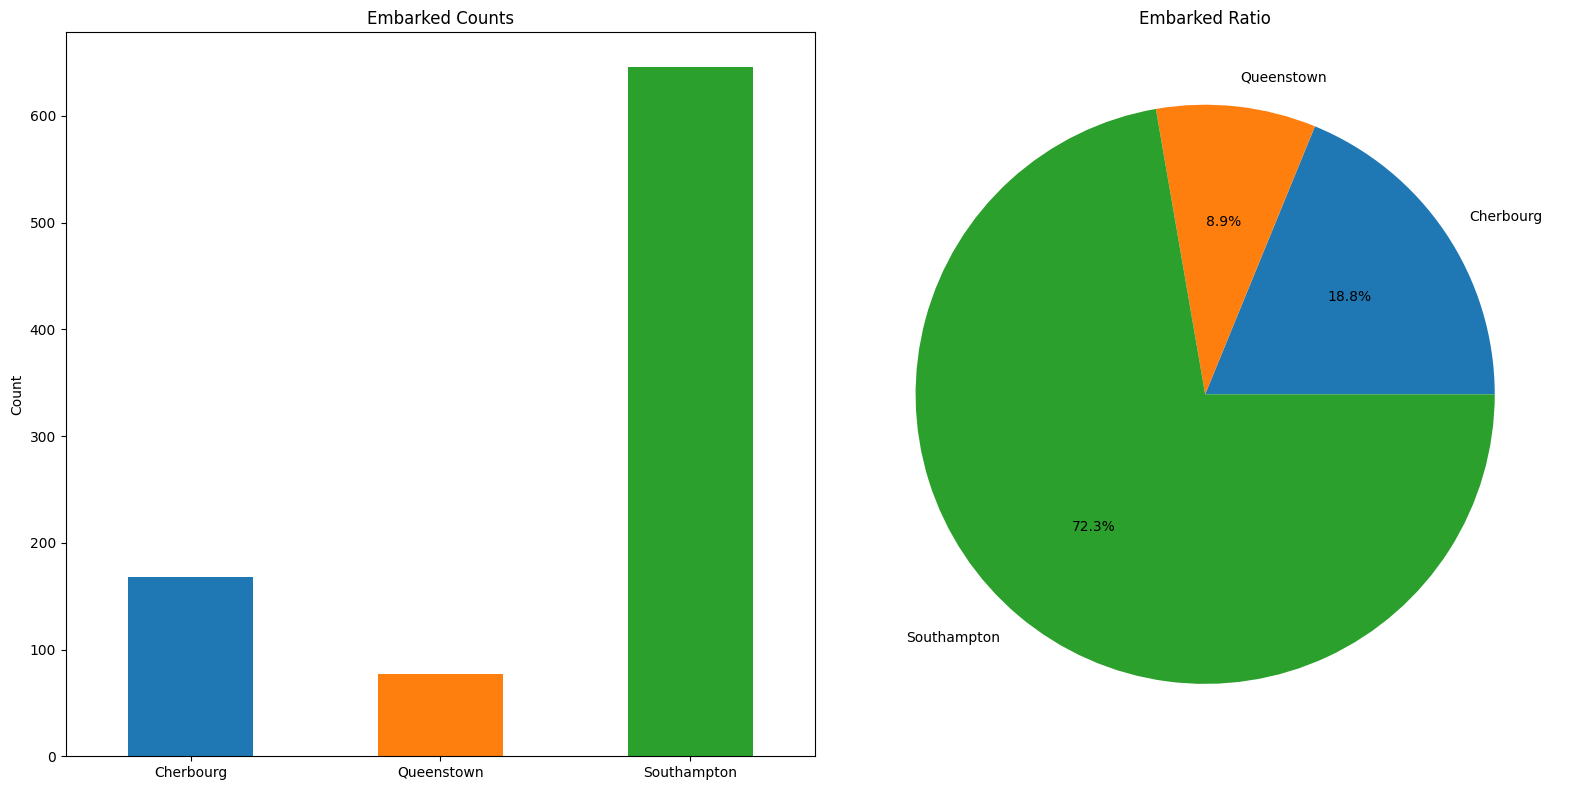

Total number of FamilySize: 891


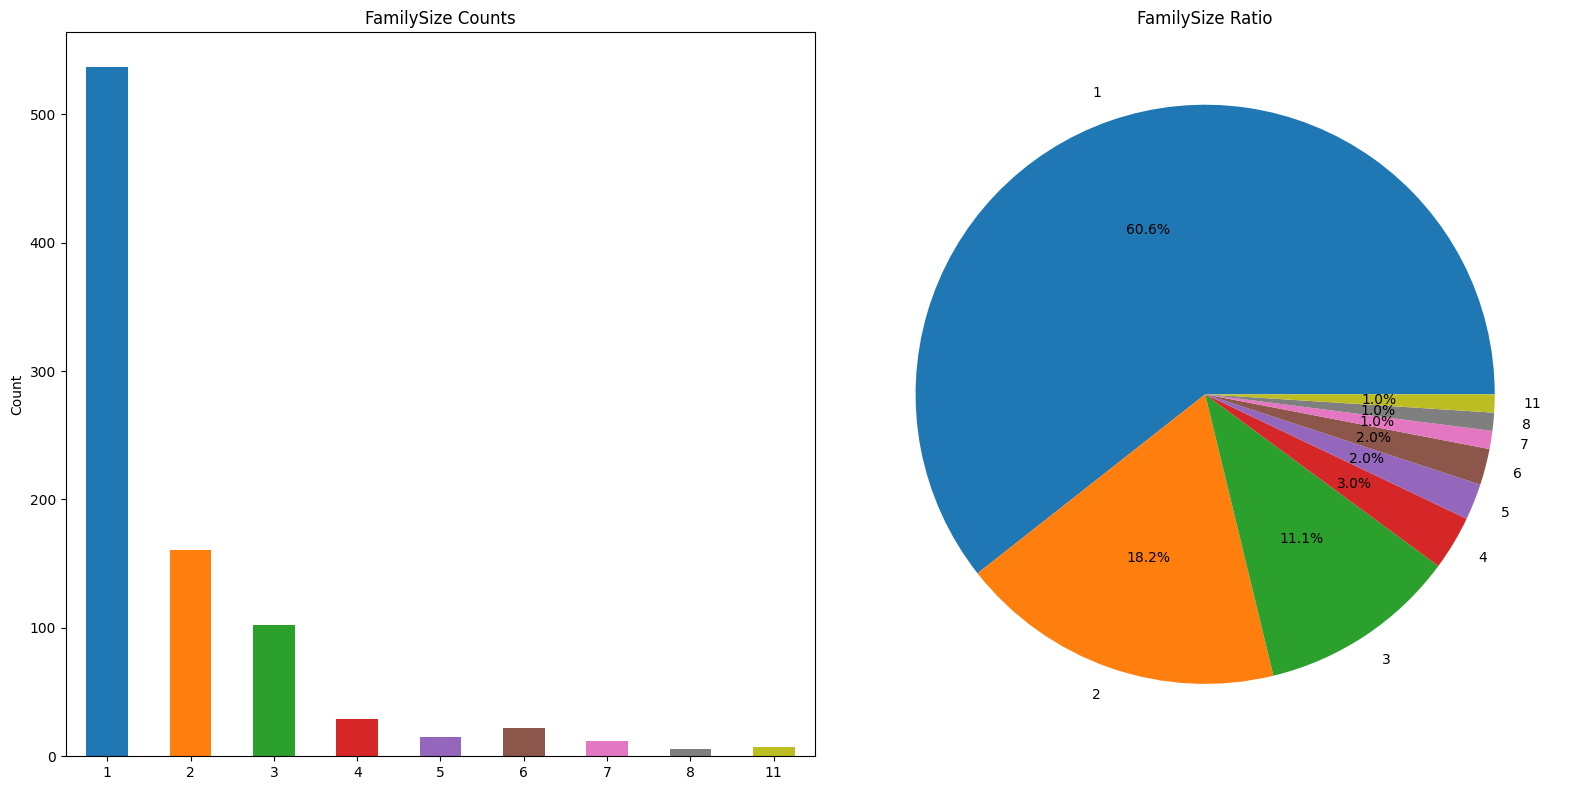

In [ ]:
for col in categorical_df.columns:
    group_by_col_and_plot(categorical_df, col)

## Bivariate/Multivariate Analysis

In [ ]:
from scipy.stats import chi2_contingency
def is_df_significant(gr, threshold=0.05):
    _, p, _, _ = chi2_contingency(gr)
    if p < threshold:
        print('The columns are statistically significant with p_value =', p)
    else:
        print('The columns are statistically insignificant with p_value =', p)
        
    

def group_by_2_cols(df, col_1, col_2):
    gr = df.groupby([col_1, col_2], observed=False).size().unstack(col_1, fill_value=0)
    print(gr)
    
    return gr

def plot_2_cols_chart(gr, col_1, col_2):
    gr_total = gr.sum(axis=1)
    gr = np.round(gr.divide(gr_total, axis=0) * 100, 2)
    
    colors = sns.color_palette(n_colors=df[col_2].nunique())
    
    # Bar chart
    ax = gr.plot(kind='bar', color=colors, title=f'Proportion of {col_1} per {col_2}')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')
    
    ax.set_xlabel('')
    ax.set_ylabel('%', rotation=1)
    ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
    
    return

Survived   No  Yes
Age               
Infant     13   31
Child      16    9
Teenager   40   30
Adult     473  271
Senior      7    1


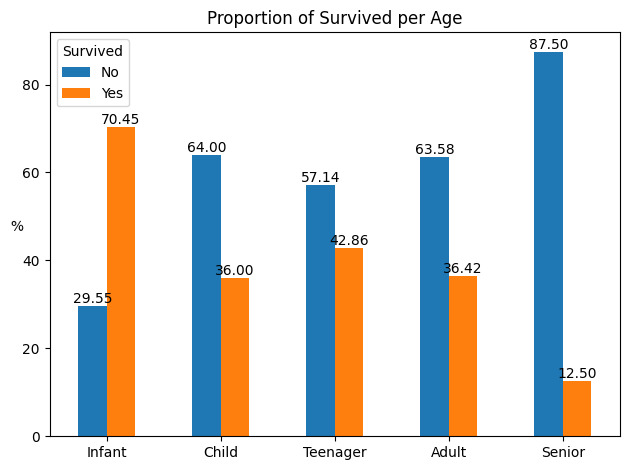

The columns are statistically insignificant with p_value = 0.00011230130477783057
Survived      No  Yes
Embarked             
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219


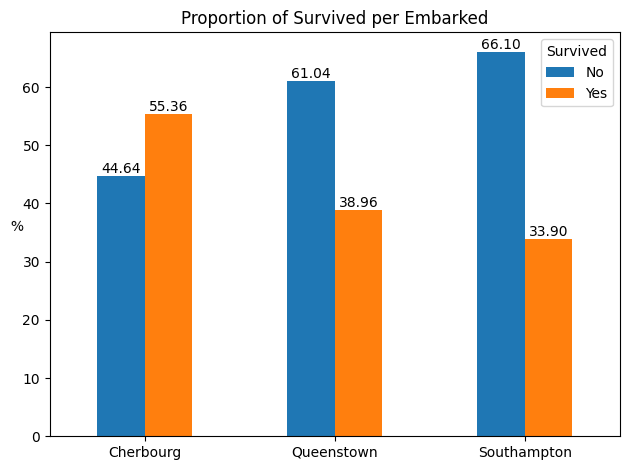

The columns are statistically significant with p_value = 2.3008626481449577e-06
Survived     No  Yes
FamilySize          
1           374  163
2            72   89
3            43   59
4             8   21
5            12    3
6            19    3
7             8    4
8             6    0
11            7    0


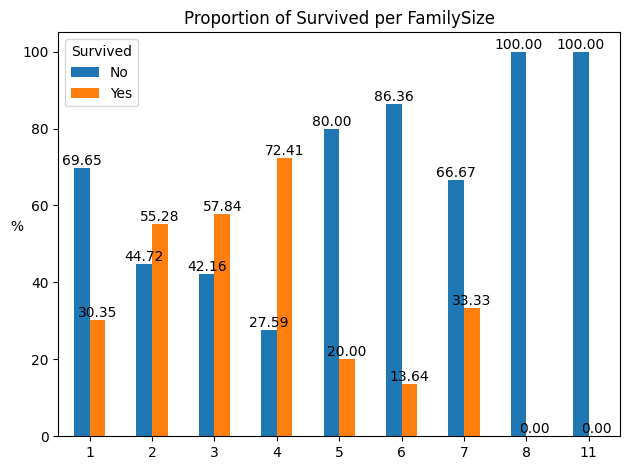

The columns are statistically significant with p_value = 3.579668975443533e-14
Survived   No  Yes
Pclass            
Lower     372  119
Middle     97   87
Upper      80  136


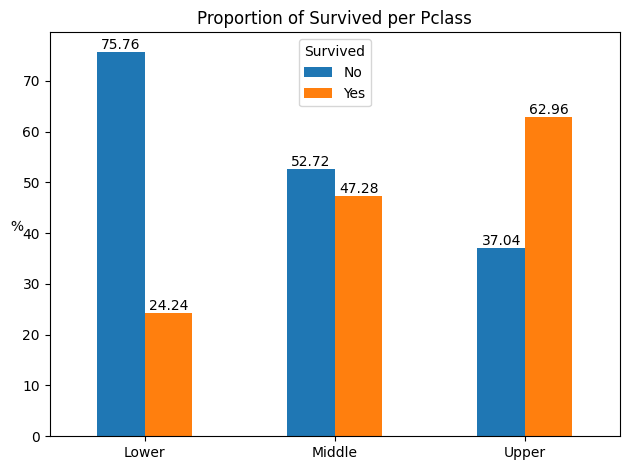

The columns are statistically significant with p_value = 4.5492517112987287e-23
Survived   No  Yes
Sex               
female     81  233
male      468  109


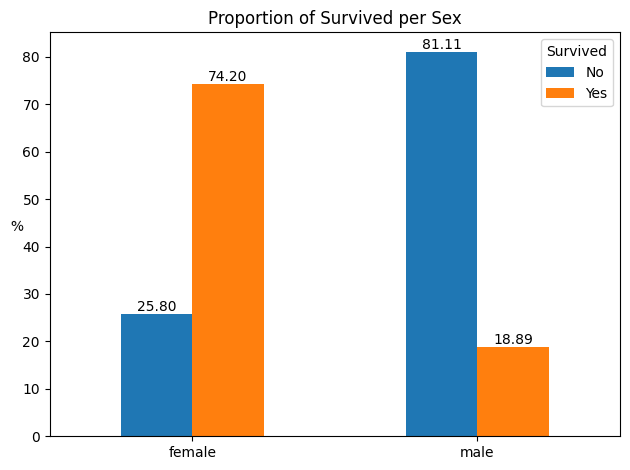

The columns are statistically significant with p_value = 1.1973570627755645e-58


In [ ]:
for col in categorical_df.columns.difference(['Survived']):
    gr = group_by_2_cols(categorical_df, col_1='Survived', col_2=col)
    plot_2_cols_chart(gr, col_1='Survived', col_2=col)
    is_df_significant(gr, threshold=0.0001)
        

By bivariate analysis of the statistically significant columns with the survivors:

- By age, infants are more likely to survive, while the opposite are more likely to seniors
- By family size, people with family size from 2-4 is more likely to survive
- By PClass, upper class is more likely to survive, while lower class is the opposite
- By sex, female is more likely to survive than male

Can group infants with female is a strong indicator of survival rate, and family size 2-4 with PClass upper as a moderately strong indicator.

## Feature Engineering

In [66]:
df = df.drop(['Name', 'Ticket', 'Fare'], axis=1)
df['is_infant_or_female'] = ((df['Age'] == 'Infant') | (df['Sex'] == 'female')).astype('int')
df['is_family_size_2_to_4_or_upper_class'] = ((df['FamilySize'] >= 2) & (df['FamilySize'] <= 4) | (df['Pclass'] == 'Upper')).astype('int')

print(df.head())

  Survived Pclass     Sex    Age     Embarked  FamilySize  \
0       No  Lower    male  Adult  Southampton           2   
1      Yes  Upper  female  Adult    Cherbourg           2   
2      Yes  Lower  female  Adult  Southampton           1   
3      Yes  Upper  female  Adult  Southampton           2   
4       No  Lower    male  Adult  Southampton           1   

   is_infant_or_female  is_family_size_2_to_4_or_upper_class  
0                    0                                     1  
1                    1                                     1  
2                    1                                     0  
3                    1                                     1  
4                    0                                     0  


In [67]:
df.to_csv('titanic_analysis_cleaned.csv', index=False)